#### [260707]_Animals 이진분류 <hr>
- 데이터 : animals_train_gray64.csv
- 학습방법 : 지도학습 + 이진분류
- 모델 및 데이터셋 클래스 생성
    * CNN, DNN
    * 과대적합시 Dropout 추가, BN추가
- ----------------------------------------

In [17]:
import pandas as pd, numpy as np, torch, sys, matplotlib.pyplot as plt, koreanize_matplotlib
import datetime

sys.path.append('.')
from animal_class import *
from dl_func import *

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from torch.optim import Adam
from torch.nn import CrossEntropyLoss

> [1] 데이터 관련

In [3]:
train_df = pd.read_csv('../Data/animals/animals_train_gray64.csv')
test_df  = pd.read_csv('../Data/animals/animals_test_gray64.csv')

print(train_df.shape, test_df.shape)
display(train_df['label'].value_counts())
display(test_df['label'].value_counts())

(229, 4097) (40, 4097)


label
1    122
0    107
Name: count, dtype: int64

label
0    20
1    20
Name: count, dtype: int64

In [ ]:
# 이미지 샘플 확인
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

for ax, lbl in zip(axes, [0, 1]):
    row = train_df[train_df['label'] == lbl].iloc[0]
    img = row[1:].values.reshape(64, 64)
    ax.imshow(img, cmap='gray')
    ax.set_title(f'label = {lbl}')

plt.show()

In [5]:
# 피쳐와 타겟 분리
feature = train_df[train_df.columns[1:]]
target  = train_df[train_df.columns[0]]

feature_test = test_df[test_df.columns[1:]]
target_test  = test_df[test_df.columns[0]]

print(feature.shape, target.shape)
print(feature_test.shape, target_test.shape)

(229, 4096) (229,)
(40, 4096) (40,)


In [6]:
# 학습용 : 검증용 = 8 : 2
x_train, x_valid, y_train, y_valid = train_test_split(feature, target,
                                                      test_size=0.2,
                                                      random_state=42,
                                                      stratify=target)
print(x_train.shape, y_train.shape)
print(x_valid.shape, y_valid.shape)

(183, 4096) (183,)
(46, 4096) (46,)


> [2] 학습 준비 - 설정값 및 사용자정의 학습 함수

In [7]:
# 학습 진행 관련 설정
epochs = 100
bs = 16

# W,B 업데이트/ 값 보정 간격
LR = 0.001

# EarlyStopping patience
patience = 8

# 학습위치
DIVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
# 모델별 학습/검증 + EarlyStopping 실행 함수
def run_experiment(model, trainDL, validDL, name):
    adam   = Adam(model.parameters(), lr=LR)
    lossFN = CrossEntropyLoss()

    lossEpoch, scoreEpoch = {'Train':[], 'Valid':[]}, {'Train':[], 'Valid':[]}
    best_valid_score, best_epoch, best_model_state, no_improve_cnt = -1, -1, None, 0

    start = datetime.datetime.now()

    for epo in range(epochs):
        t_loss, t_acc = training(model, trainDL, lossFN, adam, len(x_train), DIVICE)
        v_loss, v_acc = evaluating(model, validDL, lossFN, len(x_valid), DIVICE)

        lossEpoch['Train'].append(t_loss); scoreEpoch['Train'].append(t_acc)
        lossEpoch['Valid'].append(v_loss); scoreEpoch['Valid'].append(v_acc)

        if not epo % 5:
            print(f"[{name}][EPOCH-{epo:03}] TRAIN LOSS:{t_loss:.5f} ACC:{t_acc:.5f}", end='   ')
            print(f"VALID LOSS:{v_loss:.5f} ACC:{v_acc:.5f}")

        if v_acc > best_valid_score:
            best_valid_score = v_acc
            best_epoch = epo
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve_cnt = 0
        else:
            no_improve_cnt += 1
            if no_improve_cnt >= patience:
                print(f"[{name}] EarlyStopping at EPOCH-{epo:03} (best EPOCH-{best_epoch:03}, VALID ACC:{best_valid_score:.5f})")
                break

    elapsed = datetime.datetime.now() - start
    model.load_state_dict(best_model_state)
    print(f"[{name}] 학습 완료 - 최적 EPOCH-{best_epoch:03}  VALID ACC:{best_valid_score:.5f}  TIME:{str(elapsed).split('.')[0]}\n")

    return {'model': model, 'lossEpoch': lossEpoch, 'scoreEpoch': scoreEpoch,
            'best_epoch': best_epoch, 'best_valid_acc': best_valid_score}

> [3] 학습 진행 - 기본 DNN / CNN (과대적합 여부 확인용 베이스라인)

In [ ]:
# DNN 데이터로더 (1D)
trainDL_dnn = DataLoader(AnimalDataset(x_train, y_train, ndim=1), batch_size=bs, shuffle=True)
validDL_dnn = DataLoader(AnimalDataset(x_valid, y_valid, ndim=1), batch_size=bs)
testDL_dnn  = DataLoader(AnimalDataset(feature_test, target_test, ndim=1), batch_size=bs)

# CNN 데이터로더 (2D)
trainDL_cnn = DataLoader(AnimalDataset(x_train, y_train, ndim=2), batch_size=bs, shuffle=True)
validDL_cnn = DataLoader(AnimalDataset(x_valid, y_valid, ndim=2), batch_size=bs)
testDL_cnn  = DataLoader(AnimalDataset(feature_test, target_test, ndim=2), batch_size=bs)

In [10]:
torch.manual_seed(0)
dnn_result = run_experiment(AnimalDnn().to(DIVICE), trainDL_dnn, validDL_dnn, name='DNN(기본)')

torch.manual_seed(0)
cnn_result = run_experiment(AnimalCnn().to(DIVICE), trainDL_cnn, validDL_cnn, name='CNN(기본)')

[DNN(기본)][EPOCH-000] TRAIN LOSS:0.80827 ACC:0.51366   VALID LOSS:0.84617 ACC:0.45652
[DNN(기본)][EPOCH-005] TRAIN LOSS:0.63731 ACC:0.62295   VALID LOSS:0.66084 ACC:0.63043
[DNN(기본)][EPOCH-010] TRAIN LOSS:0.59894 ACC:0.66120   VALID LOSS:0.62768 ACC:0.63043
[DNN(기본)][EPOCH-015] TRAIN LOSS:0.67883 ACC:0.61749   VALID LOSS:0.64755 ACC:0.56522
[DNN(기본)][EPOCH-020] TRAIN LOSS:0.51432 ACC:0.75410   VALID LOSS:0.59476 ACC:0.71739
[DNN(기본)] EarlyStopping at EPOCH-022 (best EPOCH-014, VALID ACC:0.76087)
[DNN(기본)] 학습 완료 - 최적 EPOCH-014  VALID ACC:0.76087  TIME:0:00:00

[CNN(기본)][EPOCH-000] TRAIN LOSS:0.70540 ACC:0.40437   VALID LOSS:0.69373 ACC:0.45652
[CNN(기본)][EPOCH-005] TRAIN LOSS:0.67773 ACC:0.55738   VALID LOSS:0.68615 ACC:0.63043
[CNN(기본)][EPOCH-010] TRAIN LOSS:0.55700 ACC:0.68852   VALID LOSS:0.59560 ACC:0.71739
[CNN(기본)][EPOCH-015] TRAIN LOSS:0.32959 ACC:0.85792   VALID LOSS:0.50751 ACC:0.80435
[CNN(기본)][EPOCH-020] TRAIN LOSS:0.11667 ACC:0.96721   VALID LOSS:0.46023 ACC:0.76087
[CNN(기본)][EP

> [4] 학습 평가 - 로그 시각화 및 과대/과소/최적 판단

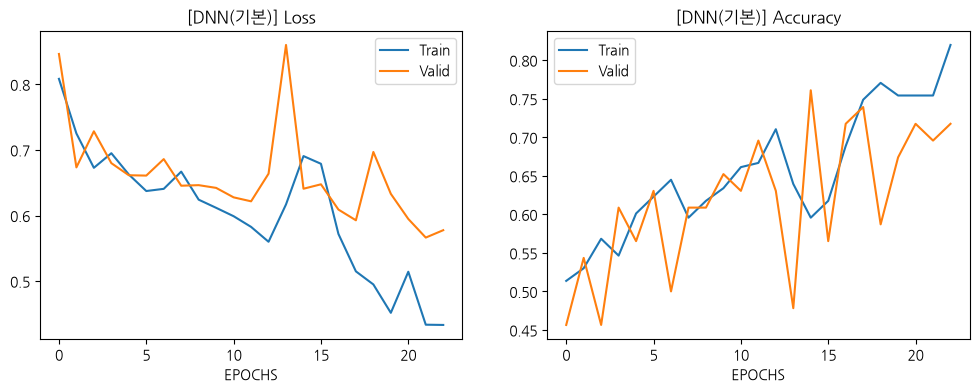

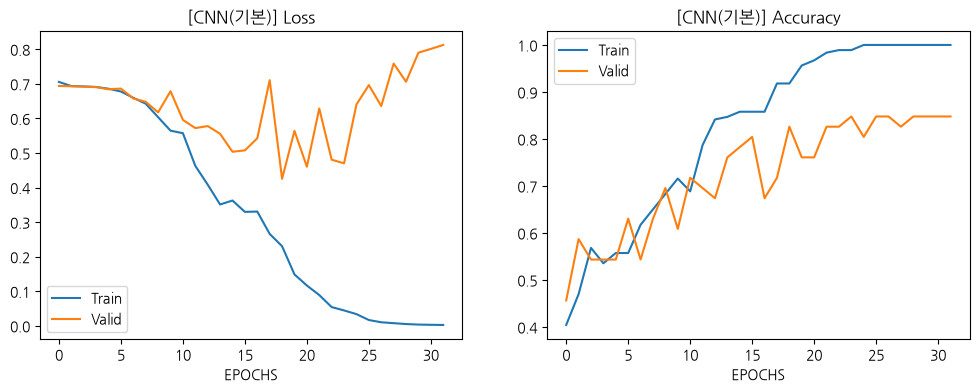

In [11]:
def plot_history(result, name):
    lossEpoch, scoreEpoch = result['lossEpoch'], result['scoreEpoch']
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(lossEpoch['Train'], label='Train')
    axes[0].plot(lossEpoch['Valid'], label='Valid')
    axes[0].set_title(f'[{name}] Loss'); axes[0].set_xlabel('EPOCHS'); axes[0].legend()

    axes[1].plot(scoreEpoch['Train'], label='Train')
    axes[1].plot(scoreEpoch['Valid'], label='Valid')
    axes[1].set_title(f'[{name}] Accuracy'); axes[1].set_xlabel('EPOCHS'); axes[1].legend()

    plt.show()

plot_history(dnn_result, 'DNN(기본)')
plot_history(cnn_result, 'CNN(기본)')

In [12]:
# 최종 테스트셋(홀드아웃) 평가
lossFN = CrossEntropyLoss()

dnn_test_loss, dnn_test_acc = evaluating(dnn_result['model'], testDL_dnn, lossFN, len(feature_test), DIVICE)
cnn_test_loss, cnn_test_acc = evaluating(cnn_result['model'], testDL_cnn, lossFN, len(feature_test), DIVICE)

print(f"[DNN(기본)][TEST] LOSS:{dnn_test_loss:.5f}  ACC:{dnn_test_acc:.5f}")
print(f"[CNN(기본)][TEST] LOSS:{cnn_test_loss:.5f}  ACC:{cnn_test_acc:.5f}")

[DNN(기본)][TEST] LOSS:0.67005  ACC:0.65000
[CNN(기본)][TEST] LOSS:0.54929  ACC:0.85000


> [5] 과대적합 개선 - Dropout + BatchNorm 추가 버전과 비교

[DNN(Dropout+BN)][EPOCH-000] TRAIN LOSS:0.77955 ACC:0.51366   VALID LOSS:0.64197 ACC:0.60870
[DNN(Dropout+BN)][EPOCH-005] TRAIN LOSS:0.45181 ACC:0.80874   VALID LOSS:0.51463 ACC:0.78261
[DNN(Dropout+BN)][EPOCH-010] TRAIN LOSS:0.29234 ACC:0.87432   VALID LOSS:0.56928 ACC:0.73913
[DNN(Dropout+BN)] EarlyStopping at EPOCH-013 (best EPOCH-005, VALID ACC:0.78261)
[DNN(Dropout+BN)] 학습 완료 - 최적 EPOCH-005  VALID ACC:0.78261  TIME:0:00:00

[CNN(Dropout+BN)][EPOCH-000] TRAIN LOSS:1.09585 ACC:0.47541   VALID LOSS:0.69222 ACC:0.54348
[CNN(Dropout+BN)][EPOCH-005] TRAIN LOSS:0.41223 ACC:0.80874   VALID LOSS:0.49113 ACC:0.78261
[CNN(Dropout+BN)][EPOCH-010] TRAIN LOSS:0.18862 ACC:0.95082   VALID LOSS:0.43945 ACC:0.84783
[CNN(Dropout+BN)][EPOCH-015] TRAIN LOSS:0.09371 ACC:0.96175   VALID LOSS:0.89202 ACC:0.76087
[CNN(Dropout+BN)] EarlyStopping at EPOCH-015 (best EPOCH-007, VALID ACC:0.84783)
[CNN(Dropout+BN)] 학습 완료 - 최적 EPOCH-007  VALID ACC:0.84783  TIME:0:00:00



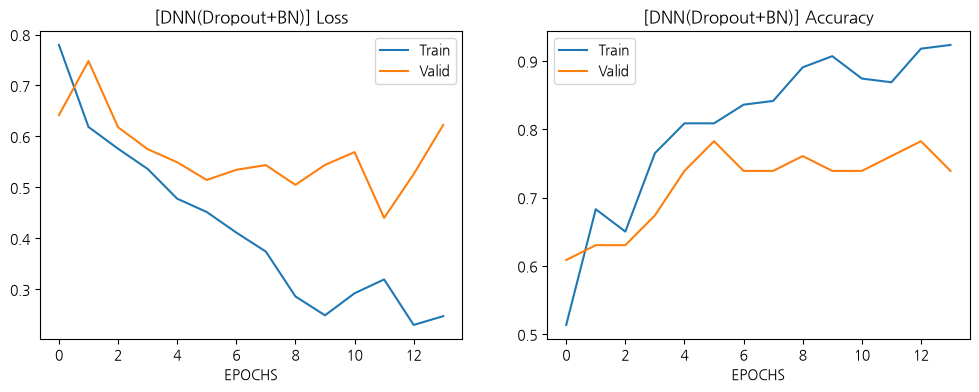

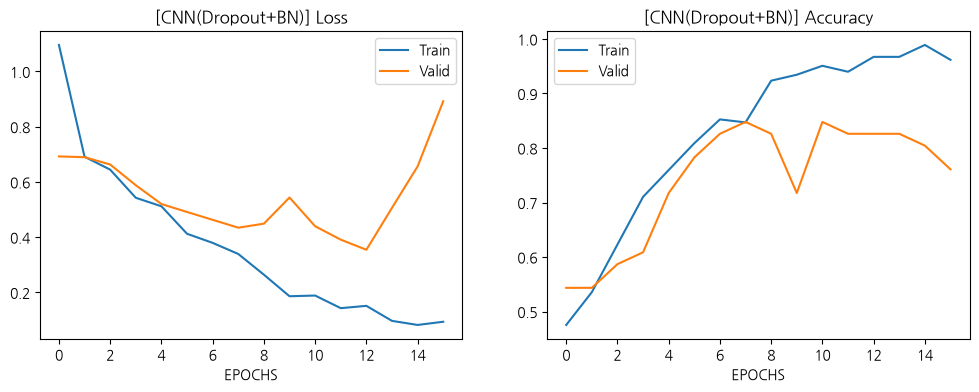

In [13]:
torch.manual_seed(0)
dnn_reg_result = run_experiment(AnimalDnnReg().to(DIVICE), trainDL_dnn, validDL_dnn, name='DNN(Dropout+BN)')

torch.manual_seed(0)
cnn_reg_result = run_experiment(AnimalCnnReg().to(DIVICE), trainDL_cnn, validDL_cnn, name='CNN(Dropout+BN)')

plot_history(dnn_reg_result, 'DNN(Dropout+BN)')
plot_history(cnn_reg_result, 'CNN(Dropout+BN)')

In [14]:
# 최종 테스트셋 평가
dnn_reg_test_loss, dnn_reg_test_acc = evaluating(dnn_reg_result['model'], testDL_dnn, lossFN, len(feature_test), DIVICE)
cnn_reg_test_loss, cnn_reg_test_acc = evaluating(cnn_reg_result['model'], testDL_cnn, lossFN, len(feature_test), DIVICE)

summary = pd.DataFrame([
    {'모델': 'DNN(기본)',        'Best Valid ACC': dnn_result['best_valid_acc'],     'Test ACC': dnn_test_acc},
    {'모델': 'DNN(Dropout+BN)', 'Best Valid ACC': dnn_reg_result['best_valid_acc'], 'Test ACC': dnn_reg_test_acc},
    {'모델': 'CNN(기본)',        'Best Valid ACC': cnn_result['best_valid_acc'],     'Test ACC': cnn_test_acc},
    {'모델': 'CNN(Dropout+BN)', 'Best Valid ACC': cnn_reg_result['best_valid_acc'], 'Test ACC': cnn_reg_test_acc},
])
display(summary)

,모델,Best Valid ACC,Test ACC
0,DNN(기본),0.760870,0.650
1,DNN(Dropout+BN),0.782609,0.625
2,CNN(기본),0.847826,0.850
3,CNN(Dropout+BN),0.847826,0.700
